In [32]:
# Data Loading and initial Data Inspection
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [33]:
# Inspect the structure of the dataset and generate summary statistics for numerical variables
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()
df.info()
df.describe()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


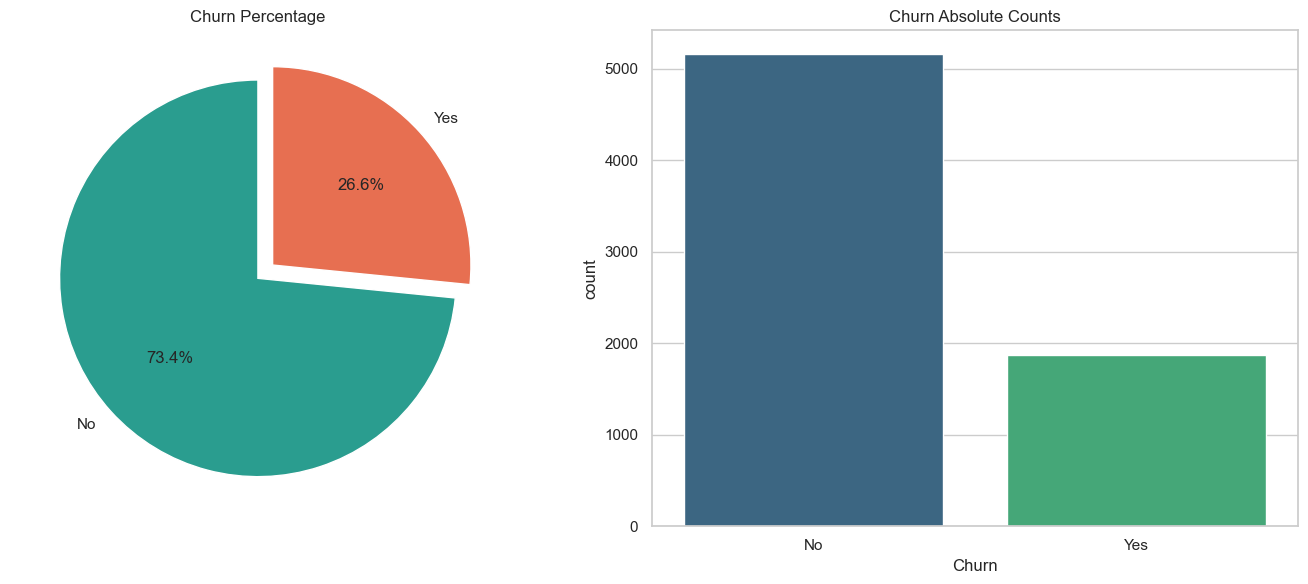

/Users/lenora/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/lenora/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/lenora/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


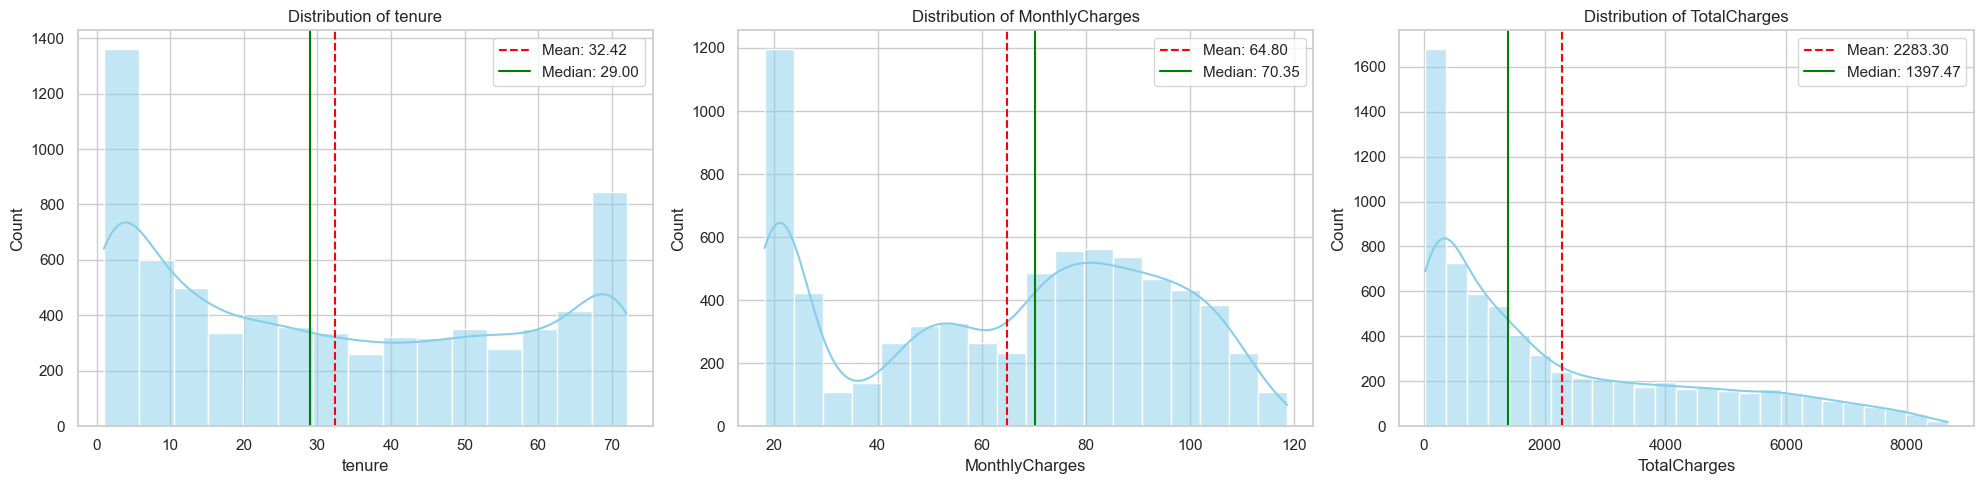

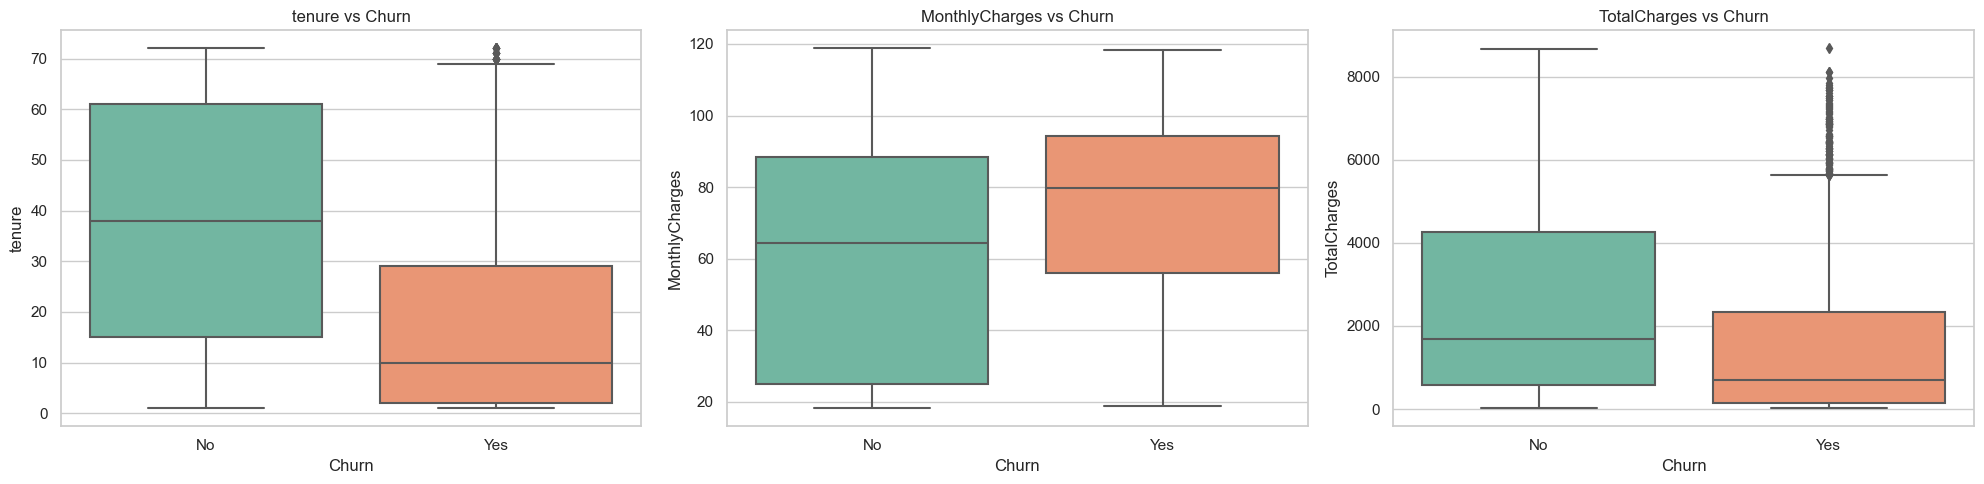

/Users/lenora/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/lenora/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/lenora/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


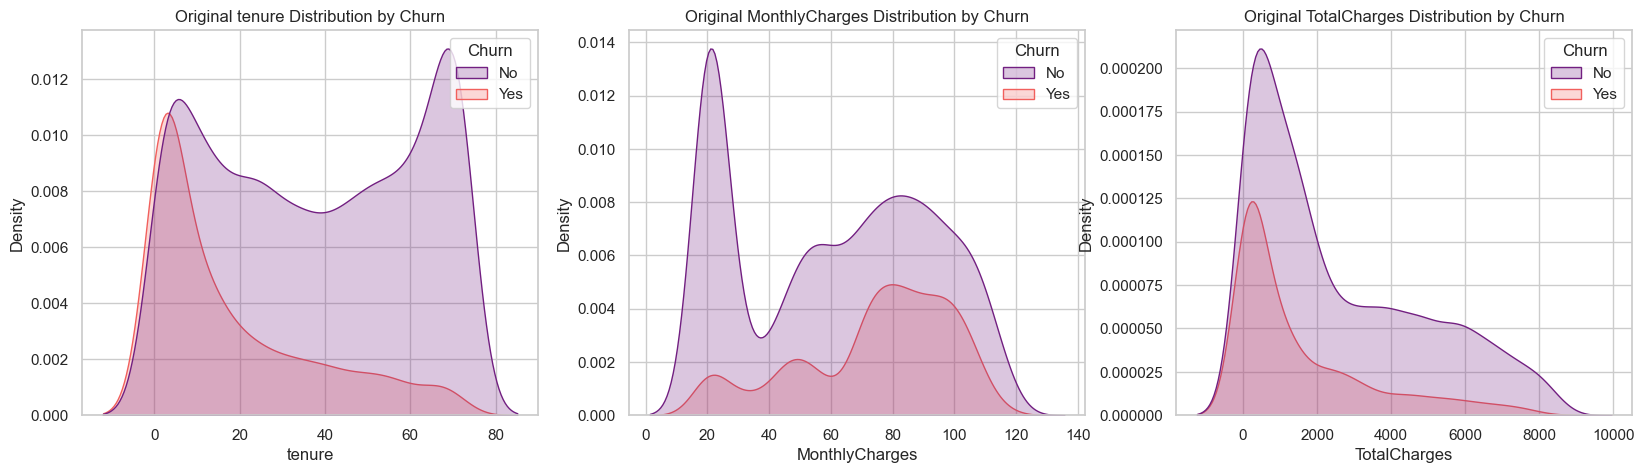

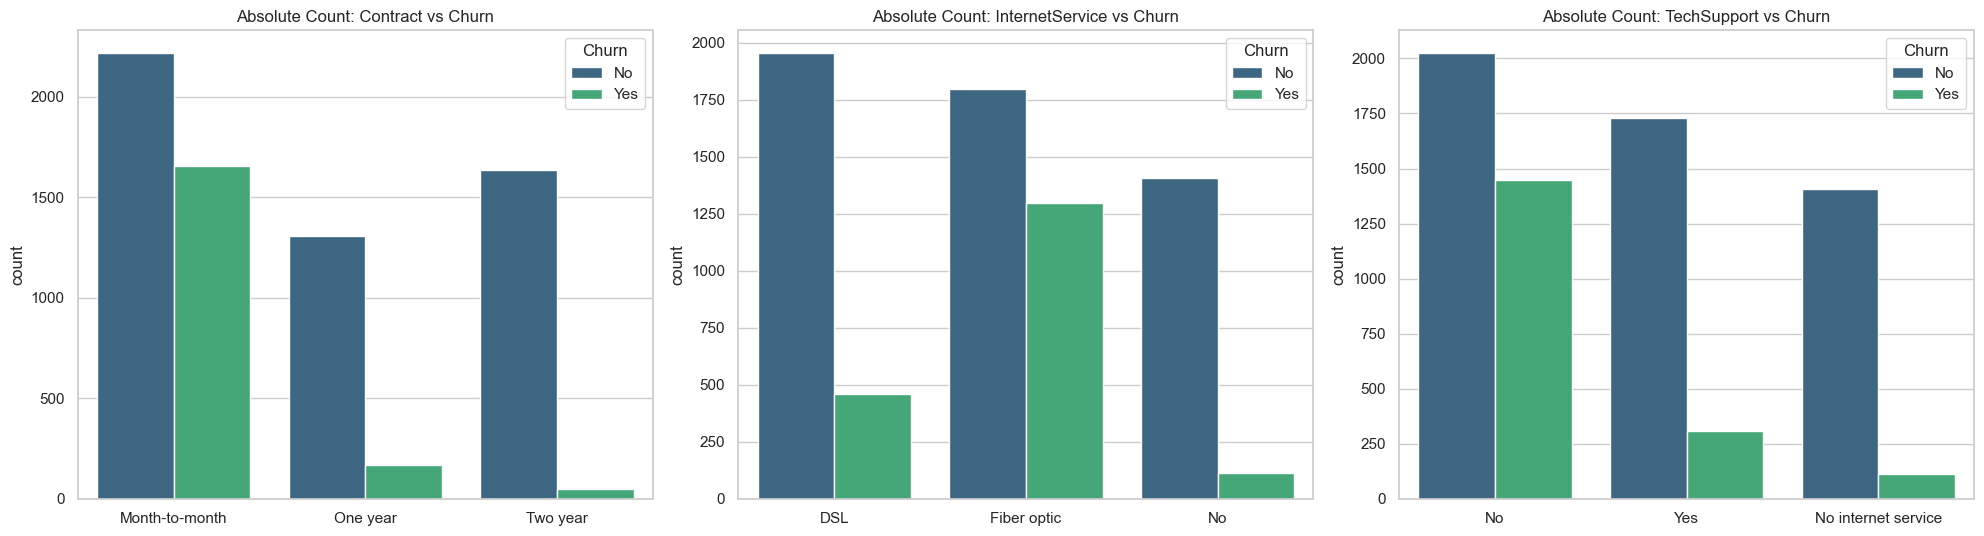

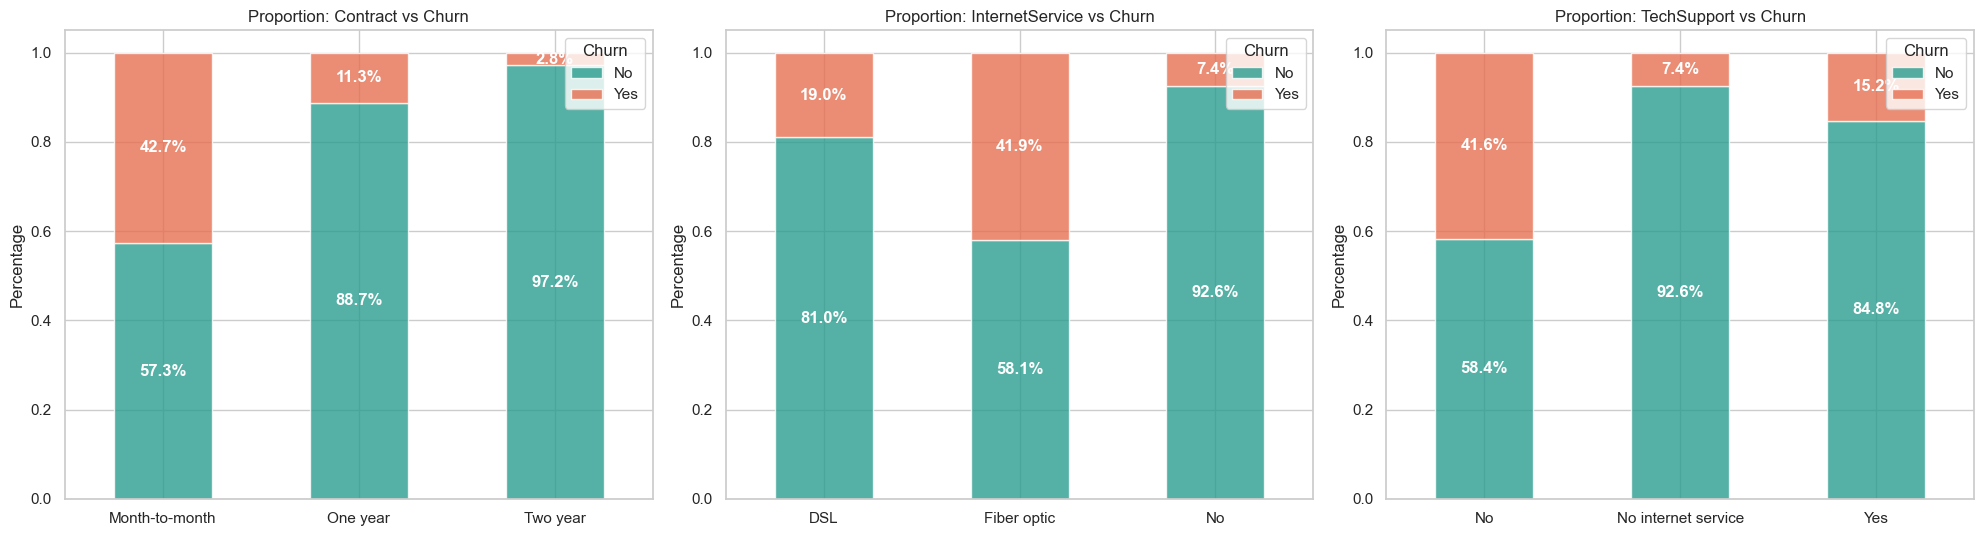

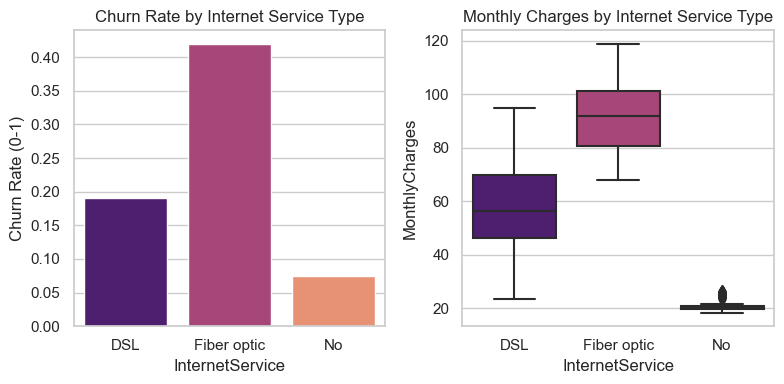

In [54]:
# Churn Distribution
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# pie chart: focus on proportion
churn_counts = df['Churn'].value_counts()
ax[0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=['#2a9d8f', '#e76f51'], explode=[0, 0.1])
ax[0].set_title('Churn Percentage')

# counting chart: focus on absolute numbers
sns.countplot(data=df, x='Churn', palette='viridis', ax=ax[1])
ax[1].set_title('Churn Absolute Counts')
plt.tight_layout()
plt.savefig("Churn Absolute Counts", dpi=300, bbox_inches='tight')
plt.show()

# Numerical Feature Distribution 
# Define numerical features
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, col in enumerate(num_features):
    # Use histplot in combination with KDE curves to observe the distribution pattern
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    
    # Basic statistics
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.2f}')
    axes[i].legend()

plt.tight_layout()
plt.savefig("Numerical Feature Distribution ", dpi=300, bbox_inches='tight')
plt.show()

# Numerical features vs Churn
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for i, col in enumerate(num_features):
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Churn')
plt.tight_layout()
plt.savefig("Numerical features vs Churn", dpi=300, bbox_inches='tight')
plt.show()
sns.set_theme(style="whitegrid")

# Create a drawing canvas layout
plt.rcParams['figure.figsize'] = (12, 8)
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, col in enumerate(num_features):
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, ax=axes[i], palette='magma')
    axes[i].set_title(f'Original {col} Distribution by Churn')

plt.savefig("Density Distribution by Churn", dpi=300, bbox_inches='tight')    
plt.show()

sns.set_theme(style="whitegrid")
features = ['Contract', 'InternetService', 'TechSupport']

# --- Absolute Count (1x3) ---
fig1, axes1 = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

for i, col in enumerate(features):
    sns.countplot(data=df, x=col, hue='Churn', ax=axes1[i], palette='viridis')
    axes1[i].set_title(f'Absolute Count: {col} vs Churn')
    axes1[i].set_xlabel('')
    axes1[i].tick_params(axis='x')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("Categorical Features: Absolute Count", dpi=300, bbox_inches='tight')
plt.show()

# --- Proportion (1x3) ---
fig2, axes2 = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

for i, col in enumerate(features):
    prop_df = (df.groupby([col, 'Churn']).size() / df.groupby(col).size()).reset_index(name='percent')
    pivot_df = prop_df.pivot(index=col, columns='Churn', values='percent')
    
    pivot_df.plot(kind='bar', stacked=True, ax=axes2[i], color=['#2a9d8f', '#e76f51'], alpha=0.8)
    axes2[i].set_title(f'Proportion: {col} vs Churn')
    axes2[i].set_ylabel('Percentage')
    axes2[i].set_xlabel('')
    axes2[i].legend(title='Churn', loc='upper right')
    axes2[i].tick_params(axis='x', rotation=0)

    for p in axes2[i].patches:
        width, height = p.get_width(), p.get_height()
        x, y = p.get_xy() 
        if height > 0.02:
            axes2[i].annotate(f'{height:.1%}', (x + width/2, y + height/2), 
                              ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("Categorical Features: Proportion", dpi=300, bbox_inches='tight')
plt.show()

# Internet Service Breakdown
plt.figure(figsize=(8, 4))

# 1. Internet service churn rate breakdown
plt.subplot(1, 2, 1)

# Calculate the proportion of 'Yes' churn cases in each service type
service_churn_rate = df.groupby('InternetService')['Churn'].apply(lambda x: (x == 'Yes').mean()).reset_index()
sns.barplot(data=service_churn_rate, x='InternetService', y='Churn', palette='magma')
plt.title('Churn Rate by Internet Service Type')
plt.ylabel('Churn Rate (0-1)')

# 2. Monthly fee distribution for different network services
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='InternetService', y='MonthlyCharges', palette='magma')
plt.title('Monthly Charges by Internet Service Type')
plt.tight_layout()
plt.savefig("Internet Service Breakdown", dpi=300, bbox_inches='tight')
plt.show()

In [35]:
# Removing Irrelevant Variables
df.drop("customerID", axis=1, inplace=True)

# Handling Missing Values
df["TotalCharges"].head()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(inplace=True)
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [36]:
cleaned_df = df.copy()
# Target Variable Transformation
cleaned_df["Churn"] = cleaned_df["Churn"].map({"Yes": 1, "No": 0})

# Encoding Categorical Variables
# Use One-Hot encoding to handle all categorical features
cleaned_df = pd.get_dummies(cleaned_df, drop_first=True)

# Convert the generated True/False values to 1/0 to prevent errors in subsequent plotting or calculations
bool_cols = cleaned_df.select_dtypes(include='bool').columns
cleaned_df[bool_cols] = cleaned_df[bool_cols].astype(int)

cleaned_df.info()
cleaned_df.to_csv("telco_churn_cleaned.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   int64  
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   Churn                                  7032 non-null   int64  
 5   gender_Male                            7032 non-null   int64  
 6   Partner_Yes                            7032 non-null   int64  
 7   Dependents_Yes                         7032 non-null   int64  
 8   PhoneService_Yes                       7032 non-null   int64  
 9   MultipleLines_No phone service         7032 non-null   int64  
 10  MultipleLines_Yes                      7032 non-null   int64  
 11  InternetS

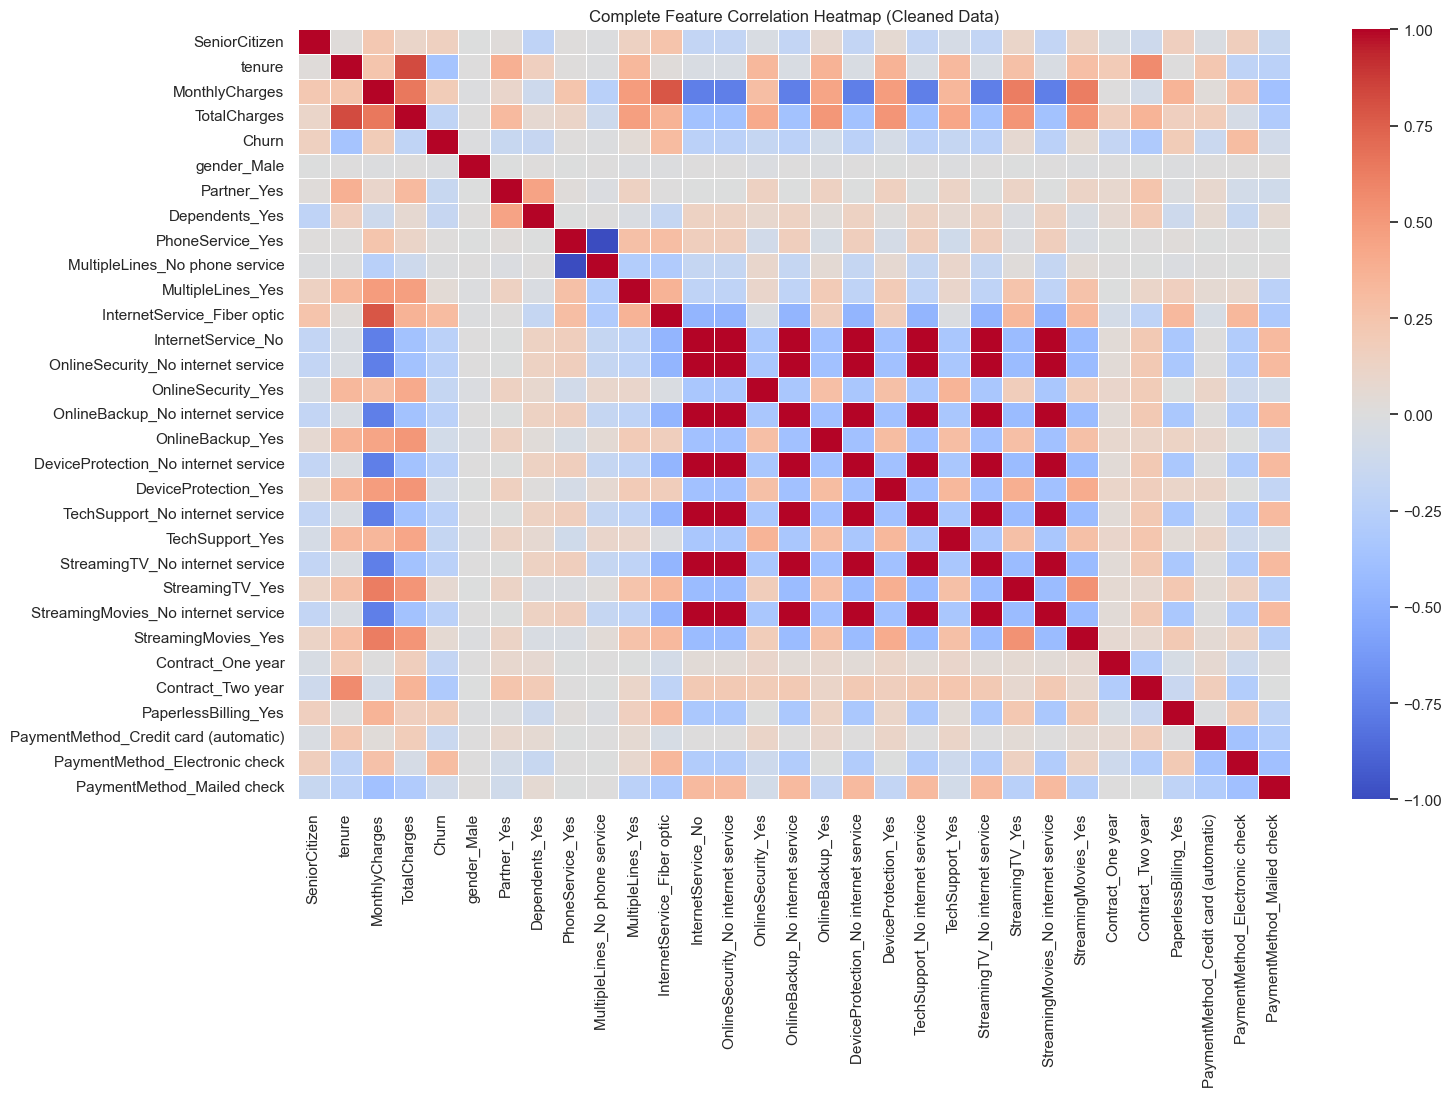

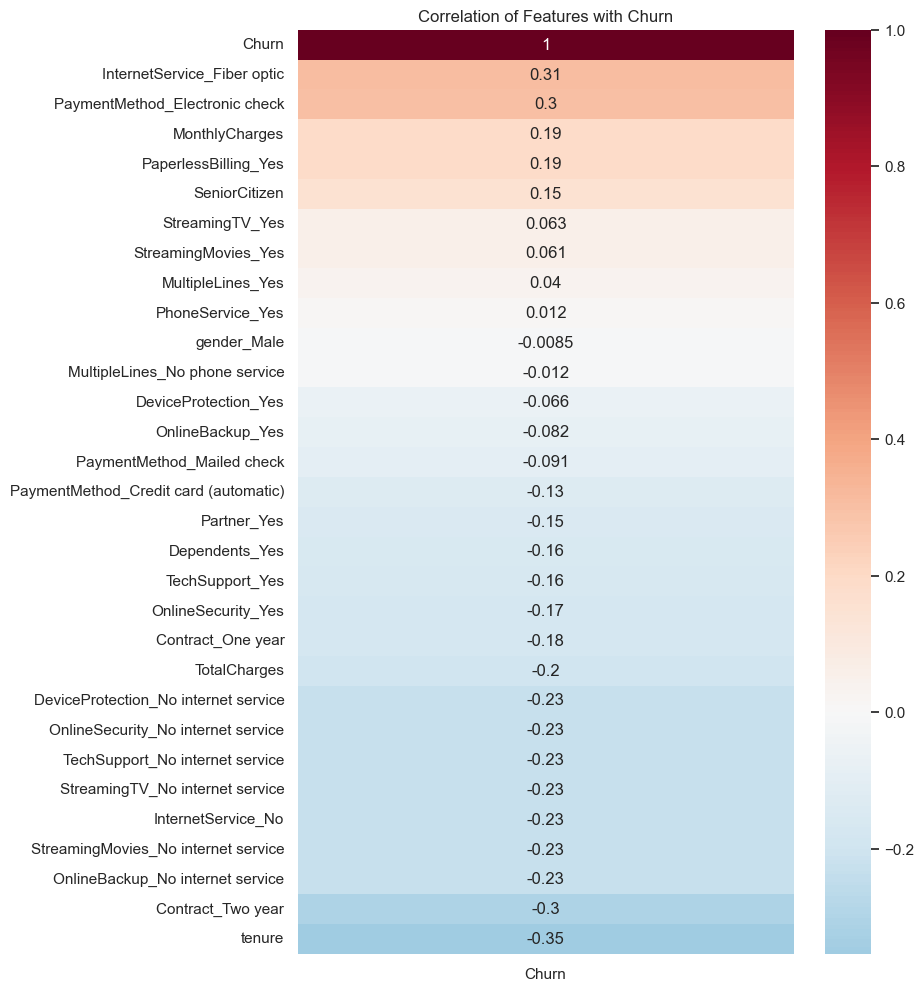

In [55]:
# Correlation heatmap
plt.figure(figsize=(16, 10))

# 1. Calculate correlation matrix
corr_matrix = cleaned_df.corr()
churn_corr = corr_matrix[['Churn']].sort_values(by='Churn', ascending=False)

# 2. Plot the heatmap
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Complete Feature Correlation Heatmap (Cleaned Data)')
plt.savefig("Correlation Heatmap", dpi=300, bbox_inches='tight')
plt.show()

# 3. Identify the top features that are most relevant to Churn
plt.figure(figsize=(8, 12))
sns.heatmap(churn_corr, annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation of Features with Churn')
plt.savefig("Correlation of Features with Churn", dpi=300, bbox_inches='tight')
plt.show()

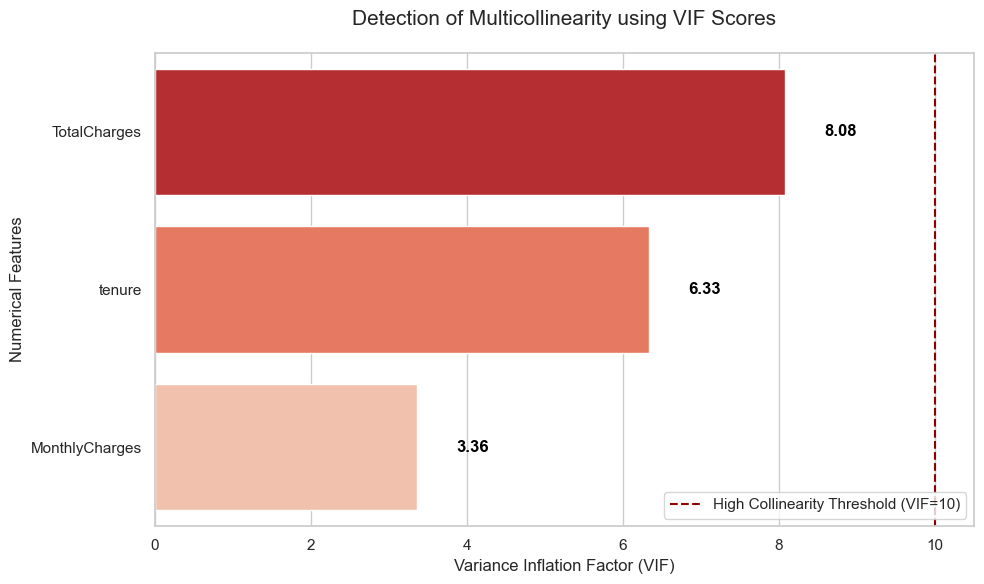

VIF ranking：
          feature       VIF
2    TotalCharges  8.079181
0          tenure  6.332432
1  MonthlyCharges  3.361075


/Users/lenora/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/lenora/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/lenora/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/lenora/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwarg

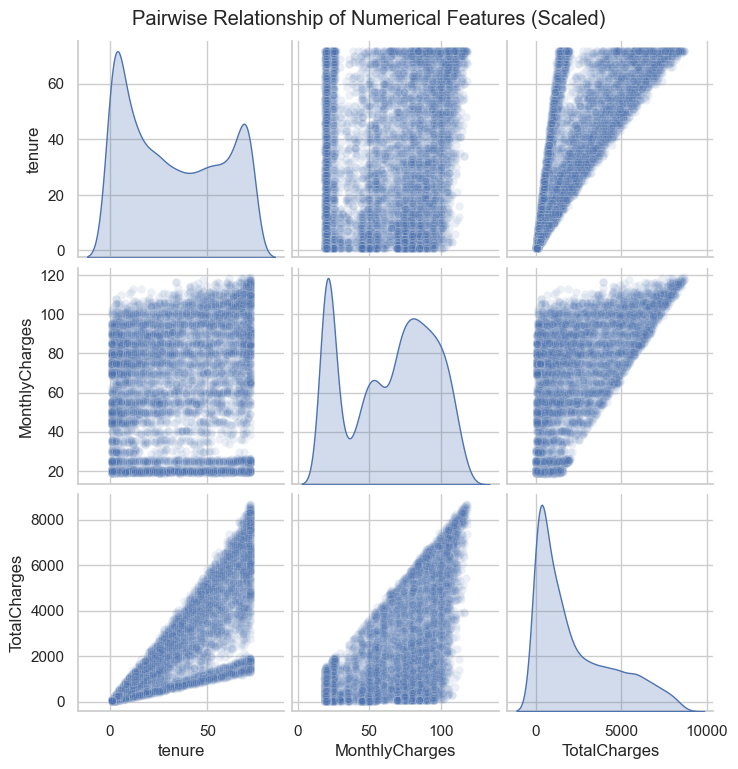

In [56]:
# Multicollinearity Check
# Use VIF to check：

# 1. Select numerical features
vif_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
vif_data = cleaned_df[vif_cols]

# 2. Calculate VIF
vif_df = pd.DataFrame()
vif_df["feature"] = vif_data.columns
vif_df["VIF"] = [variance_inflation_factor(vif_data.values, i) for i in range(len(vif_data.columns))]

# 3. Sort the VIF results in descending order
vif_df_sorted = vif_df.sort_values(by="VIF", ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x="VIF", y="feature", data=vif_df_sorted, palette="Reds_r")

# 4. Add threshold reference line 
plt.axvline(x=10, color='darkred', linestyle='--', label='High Collinearity Threshold (VIF=10)')

# 5. Chart decoration
plt.title('Detection of Multicollinearity using VIF Scores', fontsize=15, pad=20)
plt.xlabel('Variance Inflation Factor (VIF)', fontsize=12)
plt.ylabel('Numerical Features', fontsize=12)
plt.legend(loc='lower right')

for i, v in enumerate(vif_df_sorted['VIF']):
    plt.text(v + 0.5, i, f'{v:.2f}', color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig("VIF", dpi=300, bbox_inches='tight')
plt.show()
print("VIF ranking：")
print(vif_df_sorted)

# Pairplot
# 1. Select numerical features for inspection
vif_data = cleaned_df[['tenure', 'MonthlyCharges', 'TotalCharges']]

# 2. Calculate the VIF for each feature
vif_df = pd.DataFrame()
vif_df["feature"] = vif_data.columns
vif_df["VIF"] = [variance_inflation_factor(vif_data.values, i) for i in range(len(vif_data.columns))]

# 3. Visualization of collinearity (scatter matrix)
sns.pairplot(vif_data, diag_kind='kde', plot_kws={'alpha': 0.1})
plt.suptitle('Pairwise Relationship of Numerical Features (Scaled)', y=1.02)
plt.savefig("collinearity", dpi=300, bbox_inches='tight')
plt.show()

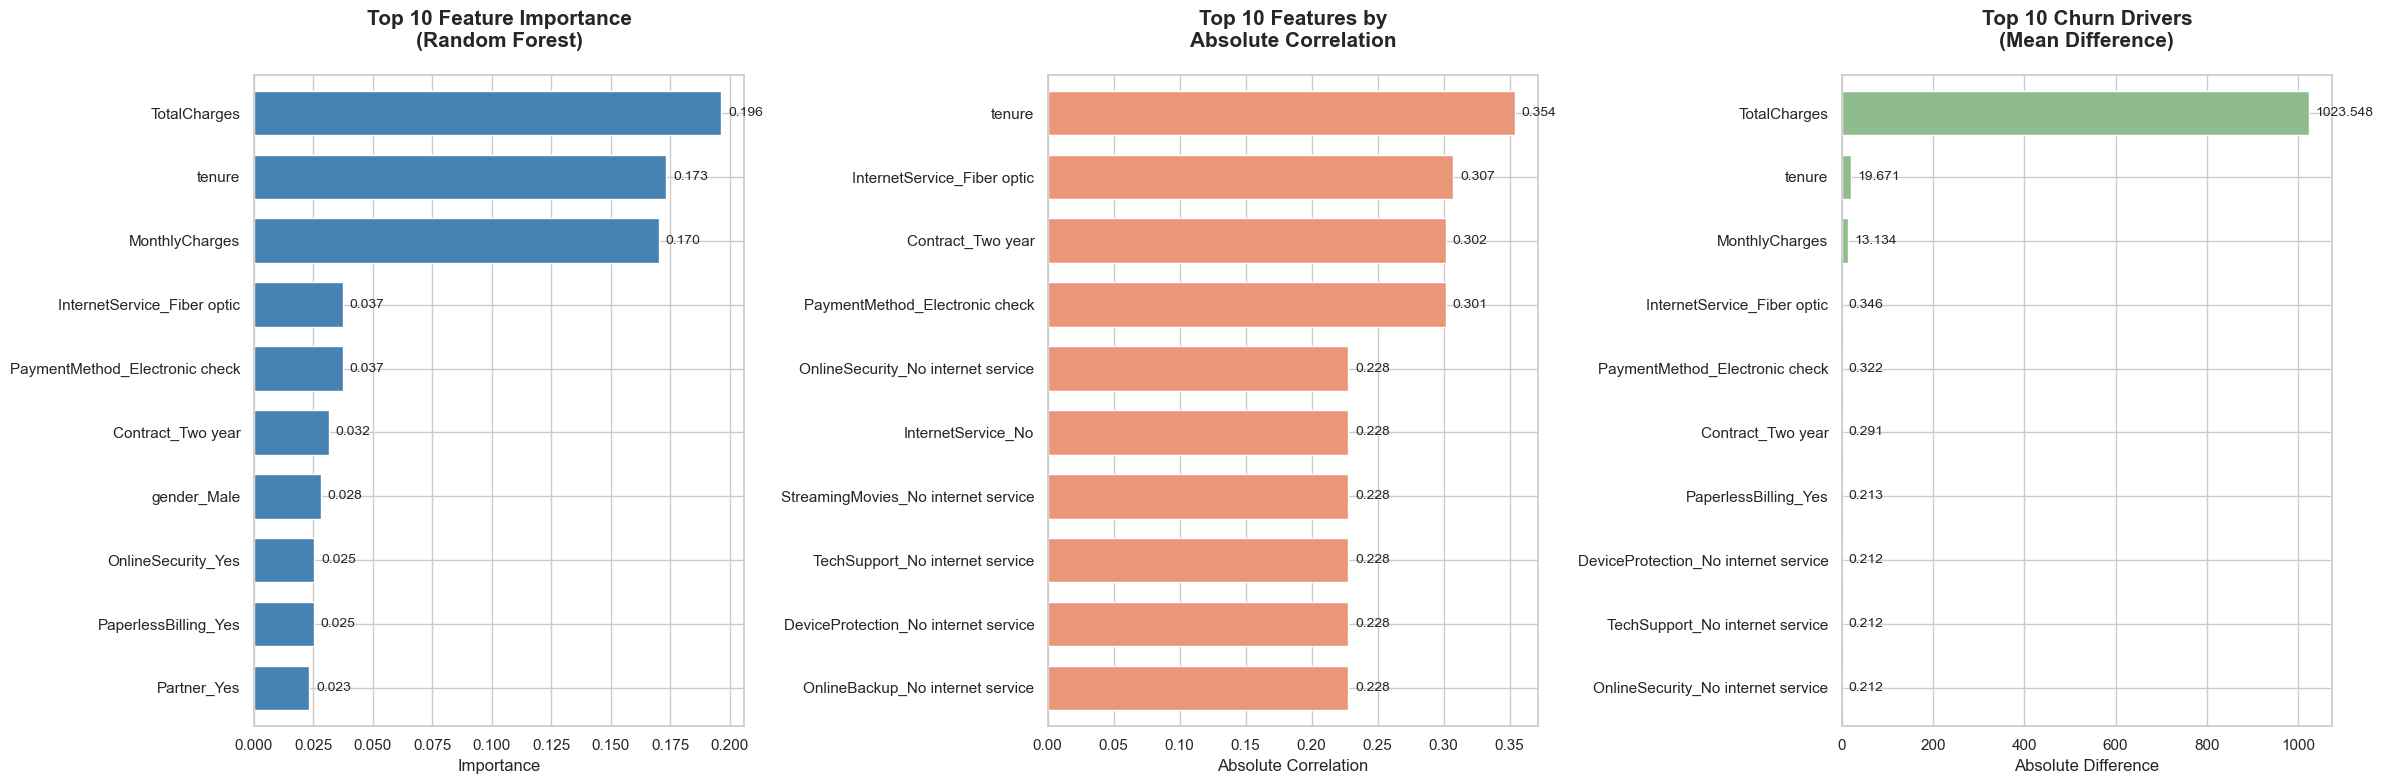

In [58]:
# Separate the independent variables (X) and the target variable (y)
X = cleaned_df.drop("Churn", axis=1)
y = cleaned_df["Churn"]
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X, y)
# Select top 10 important features
top_10_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10).sort_values()

# Top feature ranking-correlation ranking
feature_ranking_corr = cleaned_df.corr()["Churn"].abs().sort_values(ascending=False)
top_corr_features = feature_ranking_corr.drop("Churn").head(10).sort_values()

# Churn Drivers
churn_mean = cleaned_df.groupby("Churn").mean().T
churn_mean["difference"] = (churn_mean[1] - churn_mean[0]).abs()
top_churn_drivers = churn_mean["difference"].sort_values(ascending=False).head(10).sort_values()


fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(24, 8))

data_list = [top_10_rf, top_corr_features, top_churn_drivers]
titles = ["Top 10 Feature Importance\n(Random Forest)", 
          "Top 10 Features by\nAbsolute Correlation", 
          "Top 10 Churn Drivers\n(Mean Difference)"]
colors = ['#4682B4', '#E9967A', '#8FBC8F']
x_labels = ["Importance", "Absolute Correlation", "Absolute Difference"]

for i in range(3):
    data_list[i].plot(kind="barh", ax=axes[i], color=colors[i], width=0.7)
    axes[i].set_title(titles[i], fontsize=15, fontweight='bold', pad=20)
    axes[i].set_xlabel(x_labels[i], fontsize=12)
    axes[i].set_ylabel("")
    axes[i].tick_params(axis='y', labelsize=11)
    
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_width():.3f}', 
                         (p.get_width(), p.get_y() + p.get_height()/2), 
                         xytext=(5, 0), textcoords='offset points', 
                         va='center', fontsize=10)

plt.subplots_adjust(wspace=0.4)
plt.tight_layout()
plt.savefig("Comparison of feature selection results", dpi=300, bbox_inches='tight')
plt.show()

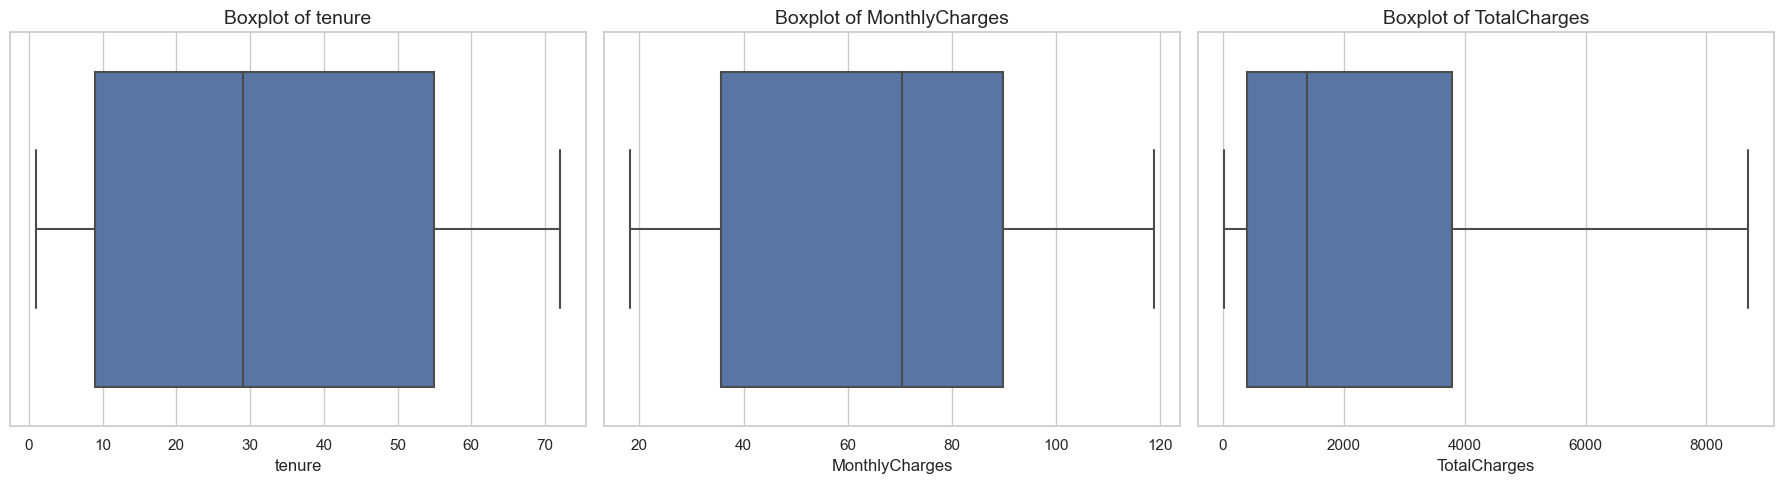

In [57]:
# Outliers detection
# 1. Select numerical variables for outlier analysis
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# 2. Visualize outliers using boxplots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(x=cleaned_df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}", fontsize=14)
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.savefig("Outlier Detection", dpi=300, bbox_inches='tight')
plt.show()

In [41]:
# Define Features (X) and Target (y)
X = cleaned_df.drop(columns=['Churn'])
y = cleaned_df['Churn']

# Split the dataset
# test_size=0.2: 80% for training, 20% for testing
# random_state=50: Get the exact same split every time you run it
# stratify=y: Maintains the same percentage of "Churn" vs "No Churn" in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=50, 
    stratify=y
)

# Verify the results
print(f"Total samples: {len(cleaned_df)}")
print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

Total samples: 7032
Training set: 5625 samples
Test set: 1407 samples
